# Tour of the Solar System
This notebook is intended to serve as a companion to the lecture on the lecture of the same name. The goal is to get our hands dirty with some mass, radius, density, distance+ data of Solar System planets and satellites.


All data is taken from https://devstronomy.martinovo.net/#/datasets#satellites


### First step: import the python packages we need
For this exercise, we will use pandas.read_csv to import the data and matplotlib.pyplot to plot it

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Load in the data

In [2]:
planets = pd.read_csv('planets.csv')

#this next line of code removes pluto from the planet sample b/c pluto is not a planet. 
#Comment the line below out if you disagree!
planets = planets.iloc[np.where(planets['planet'] != 'Pluto')]


I'm going to make some conversions below to get the quantities in more useful units. Look at the units of the raw data sets using the link above and, with your group, try to figure out what I'm doing, and discuss why.

In [3]:
au = 1.496e+8 #km
re = 6371.0 #average radius of the Earth in km
planets['mass'] = planets['mass']/5.97
planets['distance_from_sun'] = planets['distance_from_sun']*(10**6) / au
planets['radius'] = planets['diameter']/2.0/re
planets['mean_temperature'] = planets['mean_temperature'] + 273.15

print('Radius of Earth: ', planets['radius'].iloc[2], r'$R_\oplus$')

Radius of Earth:  1.0010987286140323 $R_\oplus$


One thing I did was scale planet radii to the average radius of Earth (6371 km) so that all radii are in units of $R_\oplus$. I have printed the radius of Earth in $R_\oplus$ units. This should be exactly one, but it's not. Hmm. The data file gives a diameter of 12756 km for Earth which corresponds to a radius of 6378 km. This is larger than the 6371 km I used. Why are these two numbers different?

## Part 1: The planets

You don't need to worry about the wall of code below. You may find this cell to be a useful reference when you start making plots for reports, depending on how intricate you want to go. For now, just run the cell and look at the output!

The terrestrial planets are circles of various colors and the gas giants are squares of different colors (feel free to change these as you see fit).

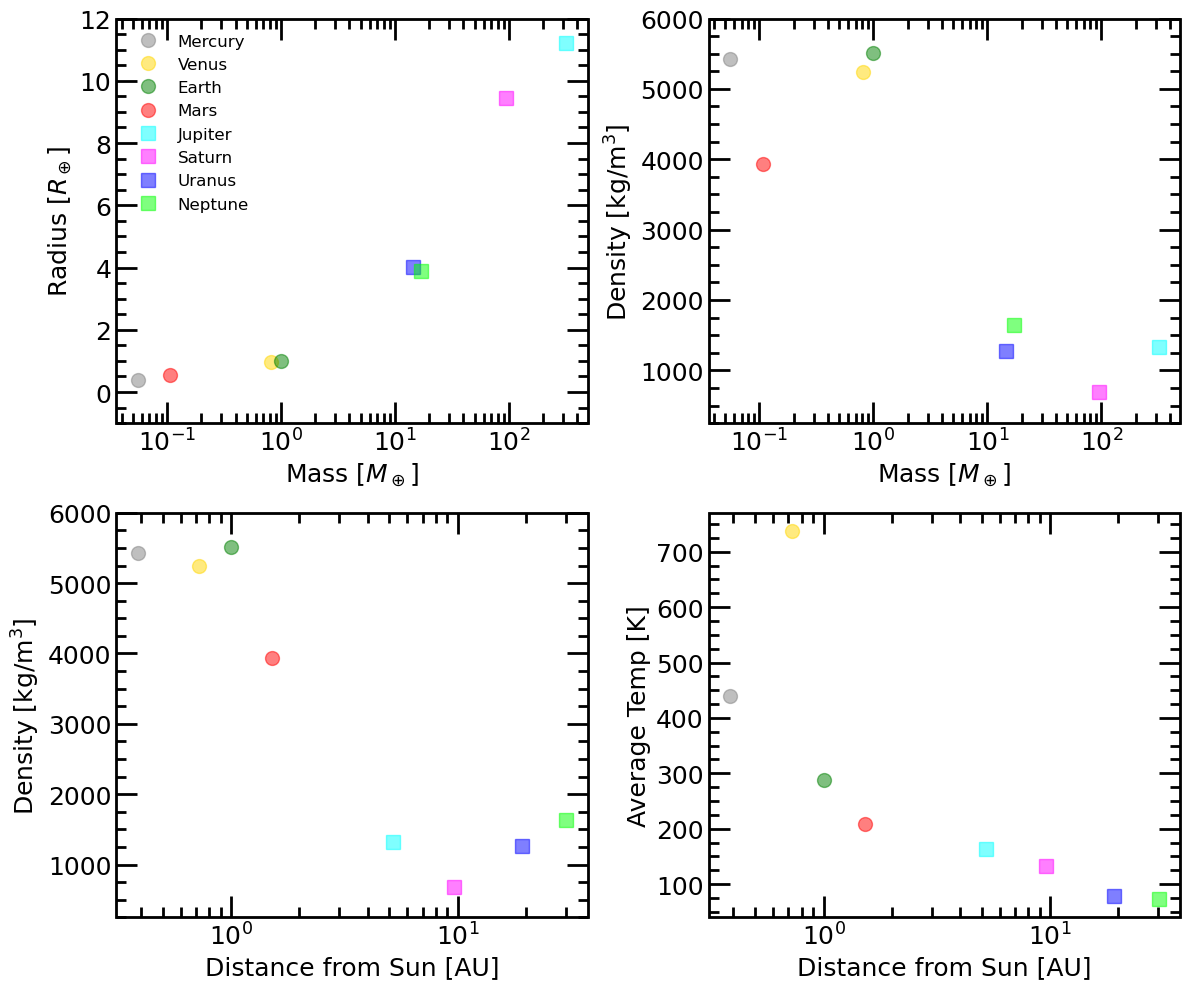

In [5]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.ticker as ticker

fig, ax = plt.subplots(2,2, figsize = (12,10))

symbol_list = ['o', 'o', 'o', 'o', 's', 's', 's', 's']
color_list = ['gray', 'gold', 'green', 'red', 'cyan', 'magenta', 'blue', 'lime']


#top left
for i in range(0, len(planets)):
    ax[0,0].plot(planets['mass'].iloc[i], planets['radius'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i], markersize = 10, alpha = 0.5, label = planets['planet'].iloc[i])

ax[0,0].legend(fontsize = 12, frameon = False)
ax[0,0].set_xscale('log')
ax[0,0].patch.set_edgecolor('black')  
ax[0,0].patch.set_linewidth(2)  
ax[0,0].tick_params(which = 'major', direction = 'in', length = 15, labelsize = 18, top = True, right = True, width = 2)
ax[0,0].tick_params(which = 'minor', direction = 'in', length = 7.5, top = True, right = True, width = 2)
ax[0,0].yaxis.set_major_locator(MultipleLocator(2.0))
ax[0,0].yaxis.set_major_formatter('{x:.0f}')
ax[0,0].set_ylim(-1, 12)
ax[0,0].yaxis.set_minor_locator(MultipleLocator(0.5))
ax[0,0].set_xlabel(r'Mass [$M_\oplus$]', fontsize = 18)
ax[0,0].set_ylabel(r'Radius [$R_\oplus$]', fontsize = 18)
ax[0,0].xaxis.set_major_locator(MultipleLocator(100.0))
majors = 10**np.linspace(-1, 2, 4)
ax[0,0].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 3, 6)]).flatten()
ax[0,0].xaxis.set_minor_locator(ticker.FixedLocator(minors))



#top right
for i in range(0, len(planets)):
    ax[0,1].plot(planets['mass'].iloc[i], planets['density'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i], markersize = 10, alpha = 0.5)
ax[0,1].set_xscale('log')
ax[0,1].patch.set_edgecolor('black')  
ax[0,1].patch.set_linewidth(2)  
ax[0,1].tick_params(which = 'major', direction = 'in', length = 15, labelsize = 18, top = True, right = True, width = 2)
ax[0,1].tick_params(which = 'minor', direction = 'in', length = 7.5, top = True, right = True, width = 2)
ax[0,1].yaxis.set_major_locator(MultipleLocator(1000.0))
ax[0,1].yaxis.set_major_formatter('{x:.0f}')
ax[0,1].set_ylim(250, 6000)
ax[0,1].yaxis.set_minor_locator(MultipleLocator(250))
ax[0,1].set_xlabel(r'Mass [$M_\oplus$]', fontsize = 18)
ax[0,1].set_ylabel(r'Density [kg/m$^3$]', fontsize = 18)
majors = 10**np.linspace(-1, 2, 4)
ax[0,1].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 3, 6)]).flatten()
ax[0,1].xaxis.set_minor_locator(ticker.FixedLocator(minors))


#bottom left
for i in range(0, len(planets)):
    ax[1,0].plot(planets['distance_from_sun'].iloc[i], planets['density'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i], markersize = 10, alpha = 0.5)
ax[1,0].set_xscale('log')
ax[1,0].patch.set_edgecolor('black')  
ax[1,0].patch.set_linewidth(2)  
ax[1,0].tick_params(which = 'major', direction = 'in', length = 15, labelsize = 18, top = True, right = True, width = 2)
ax[1,0].tick_params(which = 'minor', direction = 'in', length = 7.5, top = True, right = True, width = 2)
ax[1,0].yaxis.set_major_locator(MultipleLocator(1000.0))
ax[1,0].yaxis.set_major_formatter('{x:.0f}')
ax[1,0].set_ylim(250, 6000)
ax[1,0].yaxis.set_minor_locator(MultipleLocator(250))
ax[1,0].set_xlabel(r'Distance from Sun [AU]', fontsize = 18)
ax[1,0].set_ylabel(r'Density [kg/m$^3$]', fontsize = 18)
majors = 10**np.linspace(0, 1, 2)
ax[1,0].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-1, 2, 4)]).flatten()
ax[1,0].xaxis.set_minor_locator(ticker.FixedLocator(minors))

#bottom right
for i in range(0, len(planets)):
    ax[1,1].plot(planets['distance_from_sun'].iloc[i], planets['mean_temperature'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i], markersize = 10, alpha = 0.5)
ax[1,1].set_xscale('log')
ax[1,1].patch.set_edgecolor('black')  
ax[1,1].patch.set_linewidth(2)  
ax[1,1].tick_params(which = 'major', direction = 'in', length = 15, labelsize = 18, top = True, right = True, width = 2)
ax[1,1].tick_params(which = 'minor', direction = 'in', length = 7.5, top = True, right = True, width = 2)
ax[1,1].yaxis.set_major_locator(MultipleLocator(100.0))
ax[1,1].yaxis.set_major_formatter('{x:.0f}')
#ax[1,1].set_ylim(250, 6000)
ax[1,1].yaxis.set_minor_locator(MultipleLocator(25))
ax[1,1].set_xlabel(r'Distance from Sun [AU]', fontsize = 18)
ax[1,1].set_ylabel(r'Average Temp [K]', fontsize = 18)
majors = 10**np.linspace(0, 1, 2)
ax[1,1].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-1, 2, 4)]).flatten()
ax[1,1].xaxis.set_minor_locator(ticker.FixedLocator(minors))


plt.tight_layout()




Discuss each plot with your classmates. To start, just make some observations about each. Are there any trends? Any clusters? Any data points that seem to deviate from an observed trend.

Once you made some observations, try to interpret your observations. What do you think may be driving some of the trends/features that you observe? I.e., what is the data telling you?

### Scaled density
In the density plots, you hopefully observed two clusters of points seperating the rocky planets (Mercury, Venus, Earth, and Mars) from the gas/ice giant planets (Jupiter, Saturn, Uranus, Neptune). Density is sufficient for differentiating between planets of vastly different compositions, i.e. rock dominated vs gas dominated objects. 

If you want to understand differences in composition between two likely rocky planets with different masses or two gas dominated planets with different masses, however, density alone usually doesn't give you the whole picture. I'm not going to tell you why just yet b/c I want you to discuss with your group. For now, I'm going to introduce two scaled-density functions and use them to modify some of the previous plots.

The first one I'm calling 'rho_scaled_rock' b/c we will use it to scale the densities of the terrestrial planets. This function takes in a mass (in Earth masses) and returns the density (in kg/m3) a planet with an approximately Earth-like composition (i.e., 33% iron core and 67% silicate mantle) would have at the input mass. Try it out with 1 Earth mass -- you should get something close to 5510 kg/m3 (it isn't exact). This function is adapted from Zeng+ 2016 (https://iopscience.iop.org/article/10.3847/0004-637X/819/2/127/meta). There are some issues with the Zeng+ 2016 model, but it is easy to use and will work fine here, but we will discuss it a bit more later in the semester.

In [6]:
def rho_scaled_rock(mass):
    r = (1.07 - 0.21*0.33)*(mass**(1.0/3.7))
    return 5514.0*(mass/(r**3))

The second one I'm calling 'rho_scaled_ice' and we will use it to scale the gas/ice giants. This function gives the density a planet made of pure ice would have at mass

In [7]:
def rho_scaled_ice(mass):
    r = 1.41*mass**(1.0/3.7)
    return 5514.0*(mass/r**3)

Let's split up the rocky planets from the gasy ones and plot observed density / SCALED density as a function of mass.

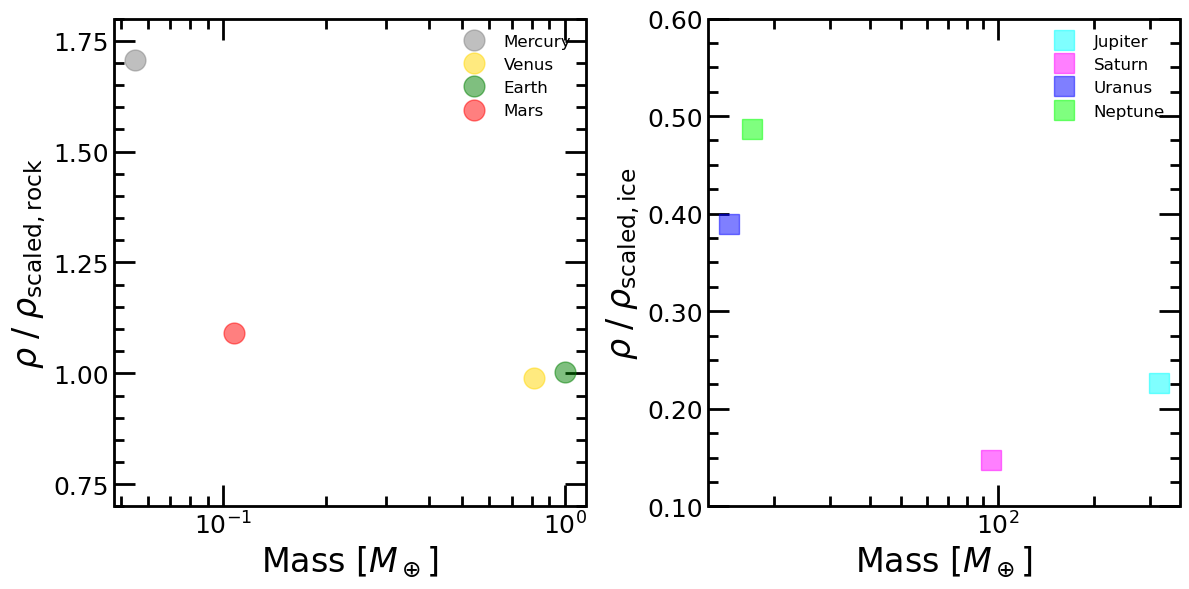

In [9]:
fig, ax = plt.subplots(1,2, figsize = (12,6))

symbol_list = ['o', 'o', 'o', 'o', 's', 's', 's', 's']
color_list = ['gray', 'gold', 'green', 'red', 'cyan', 'magenta', 'blue', 'lime']

#left
for i in range(0, 4):
    ax[0].plot(planets['mass'].iloc[i], planets['density'].iloc[i]/rho_scaled_rock(planets['mass'].iloc[i]), 
                 lw = 0, color = color_list[i], marker = symbol_list[i], markersize = 15, alpha = 0.5, 
                 label = planets['planet'].iloc[i])
ax[0].legend(fontsize = 12, frameon = False)
ax[0].set_xscale('log')
ax[0].patch.set_edgecolor('black')  
ax[0].patch.set_linewidth(2)  
ax[0].tick_params(which = 'major', direction = 'in', length = 15, labelsize = 18, top = True, right = True, width = 2)
ax[0].tick_params(which = 'minor', direction = 'in', length = 7.5, top = True, right = True, width = 2)
ax[0].yaxis.set_major_locator(MultipleLocator(0.25))
ax[0].yaxis.set_major_formatter('{x:.2f}')
ax[0].set_ylim(0.7, 1.8)
ax[0].yaxis.set_minor_locator(MultipleLocator(0.05))
ax[0].set_xlabel(r'Mass [$M_\oplus$]', fontsize = 24)
ax[0].set_ylabel(r'$\rho \; / \; \rho_\mathrm{scaled, rock}$', fontsize = 24)
ax[0].xaxis.set_major_locator(MultipleLocator(100.0))
majors = 10**np.linspace(-1, 2, 4)
ax[0].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 3, 6)]).flatten()
ax[0].xaxis.set_minor_locator(ticker.FixedLocator(minors))

#right
for i in range(4, 8):
    ax[1].plot(planets['mass'].iloc[i], planets['density'].iloc[i]/rho_scaled_ice(planets['mass'].iloc[i]), 
               lw = 0, color = color_list[i], marker = symbol_list[i], markersize = 15, alpha = 0.5, 
               label = planets['planet'].iloc[i])
ax[1].legend(fontsize = 12, frameon = False)
ax[1].set_xscale('log')
ax[1].patch.set_edgecolor('black')  
ax[1].patch.set_linewidth(2)  
ax[1].tick_params(which = 'major', direction = 'in', length = 15, labelsize = 18, top = True, right = True, width = 2)
ax[1].tick_params(which = 'minor', direction = 'in', length = 7.5, top = True, right = True, width = 2)
ax[1].yaxis.set_major_locator(MultipleLocator(0.1))
ax[1].yaxis.set_major_formatter('{x:.2f}')
ax[1].set_ylim(0.1, 0.6)
ax[1].yaxis.set_minor_locator(MultipleLocator(0.025))
ax[1].set_xlabel(r'Mass [$M_\oplus$]', fontsize = 24)
ax[1].set_ylabel(r'$\rho \; / \; \rho_\mathrm{scaled, ice}$', fontsize = 24)
majors = 10**np.linspace(-1, 2, 4)
ax[1].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 3, 6)]).flatten()
ax[1].xaxis.set_minor_locator(ticker.FixedLocator(minors))


plt.tight_layout()

How does Mercury's bulk density compare with Earth's? How does this compare with its $\rho \; / \rho_\mathrm{scaled, rock}$ value? Any ideas as to why they are similar or different?

How do the  $\rho \; / \rho_\mathrm{scaled, ice}$ values compare with each other? Which planets are most similar? Why? 

## Part II: Satellites

Let's first take a look at where moons 'live' around planets. The roche limit says that there is an inner orbital boundary for a satellite. If it journeys interior to this, it gets tidally ripped apart. In other words, this limit defines where the tidal forces from a planet equal the internal gravitation strength of the satellite. 

On the flip side, there is an outer boundary where the gravitational pull of the Sun is equal to that of the planet, i.e., where $F_\mathrm{g, sun} = F_\mathrm{g, planet}$. If a moon stays within this boundary, it is gravitationally bound to the planet and orbits it. If the moon moves beyond this boundary, it is orbitally bound by the Sun and not the planet, at which point it ceases to be a moon.

Both of these boundaries are dependent on the individual properties of a satellite. Here, we are just going to make some characteristic calculations. These calculations are most illustrative when we have a large sample of moons, so let's focus on the gas/ice giants.


In [10]:
satellite_dists = pd.read_csv('satellite_semi_major_axes.csv')
satellite_dists = satellite_dists.iloc[np.where(satellite_dists['Planet']!='Pluto')]

I have defined two functions below. The first calculates the approximate distance from a planet where its gravitational force is in balance with the Sun's. It takes in the mass of the planet in Earth masses and the orbital distance of the planet in AU. The function returns the distance (in km) from the planet where $F_\mathrm{g, sun} = F_\mathrm{g, planet}$. There are some different reference frames being thrown around here, so please ask if you are confused what I mean!!


The second equation calculates the inner roche limit. This is a function of the satellite density, the planet density, and the radius of the planet. It doesn't matter what units you use for the two density inputs as long as they are CONSISTENT. The radius of the planet should be in Earth radii. The function returns the roche limit in km.

In [11]:
def a_equal_grav(m_planet, d_planet):
    msun = 333060.402 #mass of sun in earth masses
    dist = d_planet*au
    return np.sqrt(m_planet/msun)*dist

def roche_limit(rho_planet, rho_sat, rad_planet):
    return 2.5*((rho_planet/rho_sat)**(1.0/3.0))*rad_planet*6371.0

### Jupiter

In [12]:
jupiter = satellite_dists['a'].iloc[np.where(satellite_dists['Planet']=='Jupiter')[0]]
print('Range of satellite orbital distances (km) for Jupiter: [', min(jupiter), ', ', max(jupiter), '] km')

Range of satellite orbital distances (km) for Jupiter: [ 128000 ,  24205200 ] km


Try calculating the roche limit and outer boundaries for Jupiter using the functions I gave above. For the roche limit, the average density of Jupiter's satellites is ~2.6 g/cc. How do these compare to the range above?

### Saturn

In [13]:
saturn = satellite_dists['a'].iloc[np.where(satellite_dists['Planet']=='Saturn')[0]]
print('Range of satellite orbital distances (km) for Saturn: [', min(saturn),', ', max(saturn), '] km')

Range of satellite orbital distances (km) for Saturn: [ 133600 ,  26448100 ] km


Try calculating the roche limit and outer boundaries for Saturn using the functions I gave above. For the roche limit, the average density of Saturn's satellites is ~1.7 g/cc. How do these compare to the range above?

### The 'Potato Radius'

Earth's moon and Mar's satellites, Phobos and Deimos, are all rocky in composition, but have vastly different shapes. The Moon is spherical. Phobos & Deimos are irregular in shape, like a potato. There is a balance between the material strength of an object and its self-gravity. If an object grows large enough that its self-gravitation overcomes the strength of its constituent materials, it will reshape into a sphere. 

The function below gives the approximate radius (in km) at which an object made of materials with characteristic density rho (in g/cc here) and compressive strength sigme (in MPa). This is equation 10 from https://arxiv.org/ftp/arxiv/papers/1004/1004.1091.pdf. The link gives a range of asteroid densities from 1.5 – 3.5 g/cc and compressive strength from 4-30 MPa. Play around with these ranges to determine a range of the 'Potato' Radius. Compare your range with the radii of the Moon, Phobos, and Deimos.

In [ ]:
def pot_radius(rho, sigma):
    return 240.0*np.sqrt((sigma/10.0) / (rho/2.5))